# AI-ML Assignment - 8

## Handwritten Digit Recognition using Artificial Neural Networks (ANN)

---

### Submitted By

**Name :** Abhishek Thakur

**Registration Number :** 23MIM10078

**Application Number :** IN26011189

**Batch :** 1A

---

## Objective

The objective of this assignment is to develop an Artificial Neural Network (ANN) model for recognizing handwritten digits (0–9) using the MNIST Handwritten Digits Dataset. The assignment covers data understanding, preprocessing, ANN model development, model evaluation, and performance analysis using TensorFlow/Keras.

In [1]:
# =============================================================================
# IMPORTING REQUIRED LIBRARIES
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

print("=" * 100)
print("ALL REQUIRED LIBRARIES IMPORTED SUCCESSFULLY")
print("=" * 100)

ALL REQUIRED LIBRARIES IMPORTED SUCCESSFULLY


START OF TASK 1 : DATA UNDERSTANDING

Loading MNIST Dataset...

✅ Dataset Loaded Successfully.

FIRST FIVE RECORDS OF THE DATASET
   label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0      5    0    0    0    0    0    0    0    0    0  ...      0      0   
1      0    0    0    0    0    0    0    0    0    0  ...      0      0   
2      4    0    0    0    0    0    0    0    0    0  ...      0      0   
3      1    0    0    0    0    0    0    0    0    0  ...      0      0   
4      9    0    0    0    0    0    0    0    0    0  ...      0      0   

   28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
0      0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0      0  

[5 rows x 785 columns]

INPUT FEATURES
Number of Inp

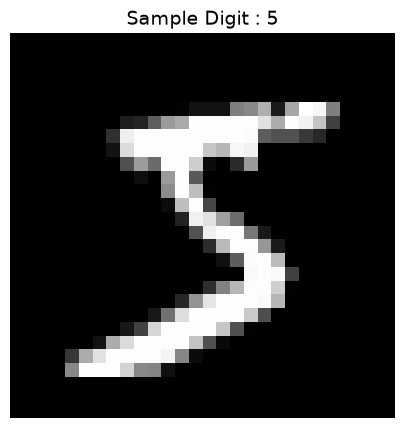


✅ TASK 1 COMPLETED SUCCESSFULLY


In [2]:
print("=" * 100)
print("START OF TASK 1 : DATA UNDERSTANDING")
print("=" * 100)

# =============================================================================
# STEP 1 : LOAD THE DATASET
# =============================================================================

print("\nLoading MNIST Dataset...\n")

df = pd.read_csv("dataset/mnist_train.csv")

print("✅ Dataset Loaded Successfully.")

# =============================================================================
# STEP 2 : DISPLAY FIRST FIVE RECORDS
# =============================================================================

print("\n" + "=" * 100)
print("FIRST FIVE RECORDS OF THE DATASET")
print("=" * 100)

print(df.head())

# =============================================================================
# STEP 3 : IDENTIFY INPUT FEATURES
# =============================================================================

print("\n" + "=" * 100)
print("INPUT FEATURES")
print("=" * 100)

input_features = df.columns[1:]

print(f"Number of Input Features : {len(input_features)}")
print(f"First 10 Features : {list(input_features[:10])}")
print(f"Last 10 Features  : {list(input_features[-10:])}")

# =============================================================================
# STEP 4 : IDENTIFY TARGET VARIABLE
# =============================================================================

print("\n" + "=" * 100)
print("TARGET VARIABLE")
print("=" * 100)

target_variable = df.columns[0]

print(f"Target Variable : {target_variable}")

# =============================================================================
# STEP 5 : DISPLAY DATASET DIMENSIONS
# =============================================================================

print("\n" + "=" * 100)
print("DATASET DIMENSIONS")
print("=" * 100)

rows, columns = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {columns}")

# =============================================================================
# STEP 6 : DISPLAY DATASET INFORMATION
# =============================================================================

print("\n" + "=" * 100)
print("DATASET SUMMARY")
print("=" * 100)

df.info()

print("\n" + "=" * 100)
print("STATISTICAL SUMMARY")
print("=" * 100)

print(df.describe())

# =============================================================================
# STEP 7 : DISPLAY ONE SAMPLE HANDWRITTEN DIGIT
# =============================================================================

print("\n" + "=" * 100)
print("DISPLAYING A SAMPLE HANDWRITTEN DIGIT")
print("=" * 100)

sample_index = 0

sample_label = df.iloc[sample_index, 0]
sample_image = df.iloc[sample_index, 1:].values.reshape(28, 28)

plt.figure(figsize=(5, 5))
plt.imshow(sample_image, cmap="gray")
plt.title(f"Sample Digit : {sample_label}", fontsize=14)
plt.axis("off")
plt.show()

# =============================================================================
# TASK COMPLETION
# =============================================================================

print("\n" + "=" * 100)
print("✅ TASK 1 COMPLETED SUCCESSFULLY")
print("=" * 100)

In [3]:
print("=" * 100)
print("START OF TASK 2 : DATA PREPROCESSING")
print("=" * 100)

# =============================================================================
# STEP 1 : CHECK FOR MISSING VALUES
# =============================================================================

print("\nChecking for Missing Values...\n")

missing_values = df.isnull().sum().sum()

print(f"Total Missing Values : {missing_values}")

if missing_values == 0:
    print("✅ No Missing Values Found.")
else:
    print("❌ Missing Values Detected.")

# =============================================================================
# STEP 2 : SEPARATE FEATURES AND TARGET VARIABLE
# =============================================================================

print("\n" + "=" * 100)
print("SEPARATING FEATURES AND TARGET VARIABLE")
print("=" * 100)

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Vector Shape  : {y.shape}")

# =============================================================================
# STEP 3 : NORMALIZE PIXEL VALUES
# =============================================================================

print("\n" + "=" * 100)
print("NORMALIZING PIXEL VALUES")
print("=" * 100)

X = X.astype("float32") / 255.0

print("Normalization Completed Successfully.")
print(f"Minimum Pixel Value : {X.min():.2f}")
print(f"Maximum Pixel Value : {X.max():.2f}")

# =============================================================================
# STEP 4 : TRAIN-TEST SPLIT (80 : 20)
# =============================================================================

print("\n" + "=" * 100)
print("SPLITTING DATASET INTO TRAINING AND TESTING SETS")
print("=" * 100)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training Features : {X_train.shape}")
print(f"Testing Features  : {X_test.shape}")
print(f"Training Labels   : {y_train.shape}")
print(f"Testing Labels    : {y_test.shape}")

# =============================================================================
# STEP 5 : ONE-HOT ENCODING
# =============================================================================

print("\n" + "=" * 100)
print("CONVERTING TARGET LABELS TO CATEGORICAL FORMAT")
print("=" * 100)

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print("One-Hot Encoding Completed Successfully.")

print(f"Encoded Training Labels Shape : {y_train.shape}")
print(f"Encoded Testing Labels Shape  : {y_test.shape}")

# =============================================================================
# TASK COMPLETION
# =============================================================================

print("\n" + "=" * 100)
print("✅ TASK 2 COMPLETED SUCCESSFULLY")
print("=" * 100)

START OF TASK 2 : DATA PREPROCESSING

Checking for Missing Values...

Total Missing Values : 0
✅ No Missing Values Found.

SEPARATING FEATURES AND TARGET VARIABLE
Feature Matrix Shape : (60000, 784)
Target Vector Shape  : (60000,)

NORMALIZING PIXEL VALUES
Normalization Completed Successfully.
Minimum Pixel Value : 0.00
Maximum Pixel Value : 1.00

SPLITTING DATASET INTO TRAINING AND TESTING SETS
Training Features : (48000, 784)
Testing Features  : (12000, 784)
Training Labels   : (48000,)
Testing Labels    : (12000,)

CONVERTING TARGET LABELS TO CATEGORICAL FORMAT
One-Hot Encoding Completed Successfully.
Encoded Training Labels Shape : (48000, 10)
Encoded Testing Labels Shape  : (12000, 10)

✅ TASK 2 COMPLETED SUCCESSFULLY


In [4]:
print("=" * 100)
print("START OF TASK 3 : MODEL DEVELOPMENT")
print("=" * 100)

# =============================================================================
# STEP 1 : BUILD THE ARTIFICIAL NEURAL NETWORK (ANN)
# =============================================================================

print("\nBuilding Artificial Neural Network...\n")

model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

print("✅ ANN Model Created Successfully.")

# =============================================================================
# STEP 2 : DISPLAY MODEL ARCHITECTURE
# =============================================================================

print("\n" + "=" * 100)
print("MODEL ARCHITECTURE")
print("=" * 100)

model.summary()

# =============================================================================
# STEP 3 : COMPILE THE MODEL
# =============================================================================

print("\n" + "=" * 100)
print("COMPILING THE MODEL")
print("=" * 100)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model Compiled Successfully.")

# =============================================================================
# STEP 4 : TRAIN THE MODEL
# =============================================================================

print("\n" + "=" * 100)
print("TRAINING THE MODEL")
print("=" * 100)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("\n✅ Model Training Completed Successfully.")

# =============================================================================
# STEP 5 : PREDICT HANDWRITTEN DIGITS
# =============================================================================

print("\n" + "=" * 100)
print("PREDICTING HANDWRITTEN DIGITS")
print("=" * 100)

predictions = model.predict(X_test)

predicted_labels = predictions.argmax(axis=1)
actual_labels = y_test.argmax(axis=1)

print("\nFirst 10 Actual Labels:")
print(actual_labels[:10])

print("\nFirst 10 Predicted Labels:")
print(predicted_labels[:10])

# =============================================================================
# TASK COMPLETION
# =============================================================================

print("\n" + "=" * 100)
print("✅ TASK 3 COMPLETED SUCCESSFULLY")
print("=" * 100)

START OF TASK 3 : MODEL DEVELOPMENT

Building Artificial Neural Network...

✅ ANN Model Created Successfully.

MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


COMPILING THE MODEL
✅ Model Compiled Successfully.

TRAINING THE MODEL
Epoch 1/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 1s 643us/step - accuracy: 0.9138 - loss: 0.2984 - val_accuracy: 0.9482 - val_loss: 0.1721
Epoch 2/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 1s 604us/step - accuracy: 0.9625 - loss: 0.1226 - val_accuracy: 0.9591 - val_loss: 0.1377
Epoch 3/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 1s 572us/step - accuracy: 0.9741 - loss: 0.0840 - val_accuracy: 0.9644 - val_loss: 0.1114
Epoch 4/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 1s 587us/step - accuracy: 0.9801 - loss: 0.0622 - val_accuracy: 0.9589 - val_loss: 0.1373
Epoch 5/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 1s 566us/step - accuracy: 0.9845 - loss: 0.0475 - val_accuracy: 0.9695 - val_loss: 0.1062
Epoch 6/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 1s 589us/step - accuracy: 0.9879 - loss: 0.0373 - val_accuracy: 0.9720 - val_loss: 0.1039
Epoch 7/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 1s 568us/step - accuracy: 0.9898 - loss: 0.0307 - val_accuracy: 0.9685 - val_loss: 0.1244
Epoc

START OF TASK 4 : MODEL EVALUATION

Evaluating the model on the test dataset...

Test Loss     : 0.1114
Test Accuracy : 0.9754
Test Accuracy : 97.54%

CONFUSION MATRIX


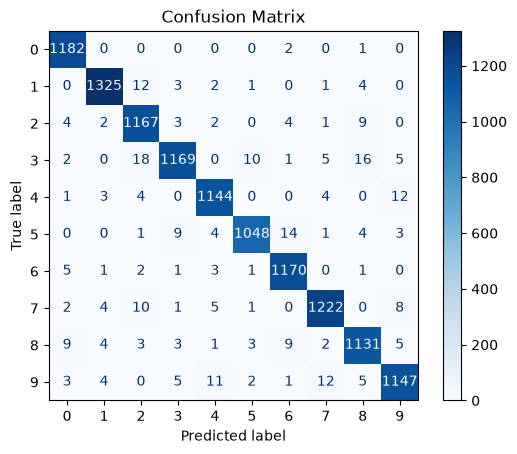


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1185
           1       0.99      0.98      0.98      1348
           2       0.96      0.98      0.97      1192
           3       0.98      0.95      0.97      1226
           4       0.98      0.98      0.98      1168
           5       0.98      0.97      0.97      1084
           6       0.97      0.99      0.98      1184
           7       0.98      0.98      0.98      1253
           8       0.97      0.97      0.97      1170
           9       0.97      0.96      0.97      1190

    accuracy                           0.98     12000
   macro avg       0.98      0.98      0.98     12000
weighted avg       0.98      0.98      0.98     12000


ACCURACY VS EPOCH


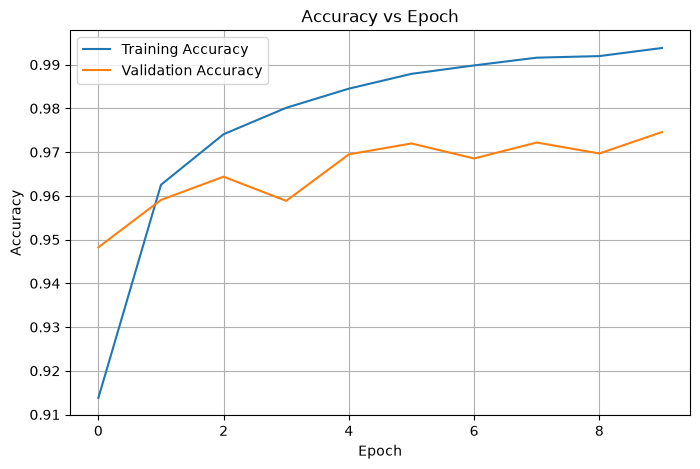


LOSS VS EPOCH


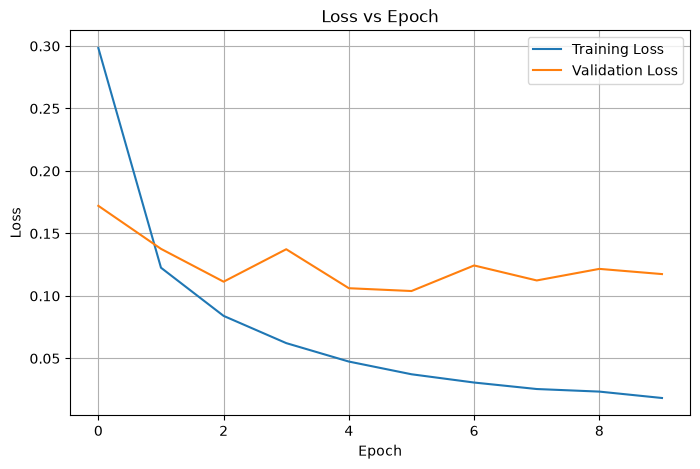


OBSERVATIONS
1. The ANN achieved high classification accuracy on the MNIST handwritten digit dataset.
2. Training and validation accuracy increased steadily over the epochs, indicating effective learning.
3. The training and validation loss decreased consistently, showing good model convergence.
4. The confusion matrix indicates that most digits were correctly classified, with only a few misclassifications among visually similar digits.

✅ TASK 4 COMPLETED SUCCESSFULLY


In [5]:
print("=" * 100)
print("START OF TASK 4 : MODEL EVALUATION")
print("=" * 100)

# =============================================================================
# STEP 1 : EVALUATE MODEL ON TEST DATA
# =============================================================================

print("\nEvaluating the model on the test dataset...\n")

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

# =============================================================================
# STEP 2 : CONFUSION MATRIX
# =============================================================================

print("\n" + "=" * 100)
print("CONFUSION MATRIX")
print("=" * 100)

cm = confusion_matrix(actual_labels, predicted_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix")
plt.show()

# =============================================================================
# STEP 3 : CLASSIFICATION REPORT
# =============================================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT")
print("=" * 100)

print(classification_report(actual_labels, predicted_labels))

# =============================================================================
# STEP 4 : ACCURACY VS EPOCH
# =============================================================================

print("\n" + "=" * 100)
print("ACCURACY VS EPOCH")
print("=" * 100)

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# =============================================================================
# STEP 5 : LOSS VS EPOCH
# =============================================================================

print("\n" + "=" * 100)
print("LOSS VS EPOCH")
print("=" * 100)

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# =============================================================================
# STEP 6 : OBSERVATIONS
# =============================================================================

print("\n" + "=" * 100)
print("OBSERVATIONS")
print("=" * 100)

print("1. The ANN achieved high classification accuracy on the MNIST handwritten digit dataset.")
print("2. Training and validation accuracy increased steadily over the epochs, indicating effective learning.")
print("3. The training and validation loss decreased consistently, showing good model convergence.")
print("4. The confusion matrix indicates that most digits were correctly classified, with only a few misclassifications among visually similar digits.")

# =============================================================================
# TASK COMPLETION
# =============================================================================

print("\n" + "=" * 100)
print("✅ TASK 4 COMPLETED SUCCESSFULLY")
print("=" * 100)

In [6]:
print("=" * 100)
print("START OF TASK 5 : CONCLUSION")
print("=" * 100)

print("""
CONCLUSION

The Artificial Neural Network (ANN) was successfully developed to classify handwritten digits using the MNIST dataset. The dataset was preprocessed by checking for missing values, normalizing pixel values, splitting it into training and testing sets, and applying one-hot encoding to the target labels. The ANN architecture, consisting of two hidden layers with ReLU activation and a Softmax output layer, achieved high classification accuracy on the test dataset.

Hidden layers play a vital role in ANN by learning complex patterns and extracting meaningful features from the input data, enabling accurate classification of handwritten digits. One major advantage of Deep Learning over traditional Machine Learning is its ability to automatically learn features from raw data without requiring manual feature engineering. However, a limitation of ANN is that it requires a large amount of training data and considerable computational resources for effective training. Overall, the developed ANN model proved to be efficient and reliable for handwritten digit recognition.
""")

print("=" * 100)
print("✅ TASK 5 COMPLETED SUCCESSFULLY")
print("=" * 100)

START OF TASK 5 : CONCLUSION

CONCLUSION

The Artificial Neural Network (ANN) was successfully developed to classify handwritten digits using the MNIST dataset. The dataset was preprocessed by checking for missing values, normalizing pixel values, splitting it into training and testing sets, and applying one-hot encoding to the target labels. The ANN architecture, consisting of two hidden layers with ReLU activation and a Softmax output layer, achieved high classification accuracy on the test dataset.

Hidden layers play a vital role in ANN by learning complex patterns and extracting meaningful features from the input data, enabling accurate classification of handwritten digits. One major advantage of Deep Learning over traditional Machine Learning is its ability to automatically learn features from raw data without requiring manual feature engineering. However, a limitation of ANN is that it requires a large amount of training data and considerable computational resources for effectiv